# Netflix Content Analysis — Business Insights & Recommendations

### Executive Summary
This analysis explores Netflix’s catalogue of TV shows and movies to identify **what types of content to produce** and **how Netflix can grow its business in different countries**.  
By examining the distribution of titles across genres, countries, release years, and formats, we uncover trends in Netflix’s strategic content expansion.


**Problem Statements:**
1.How has the number of movies released per year changed over the last 20-30 years?

2.Comparison of tv shows vs. movies.

3.What is the best time to launch a TV show?

4.Analysis of actors/directors of different types of shows/movies.

5.Does Netflix has more focus on TV Shows than movies in recent years

6.Understanding what content is available in different countries

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv('/content/netflix.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
print('Shape of CSV:',data.shape)
print("Null values in Dataset:",data.isnull().sum())


Shape of CSV: (8807, 12)
Null values in Dataset: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Total titles and type counts
print(data['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


**Observation**:
The dataset contains ~8800 titles and 12 attributes.
Columns like `director`, `cast`, and `country` have several missing values.

The `date_added` column was converted to datetime format for analysis.

 Data types are mostly strings and objects; categorical conversion can optimize memory

In [ ]:
# Missing data summary
missing = data.isna().sum()
missing[missing > 0]

# Duration outliers
movies = data[data['type']=='Movie']
Q1 = movies['duration_num'].quantile(0.25)
Q3 = movies['duration_num'].quantile(0.75)
IQR = Q3 - Q1
outliers = movies[(movies['duration_num'] < Q1 - 1.5*IQR) | (movies['duration_num'] > Q3 + 1.5*IQR)]
print("Outlier count:", len(outliers))


Outlier count: 450


In [ ]:
# Convert date_added to datetime
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
# Extract year and month
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month
# Fill missing country names
data.fillna({'country':'Unknown'}, inplace=True)
data['duration_num'] = data['duration'].str.extract(r'(\d+)').astype(float)
data['duration_unit'] = np.where(data['duration'].str.contains('Season', na=False), 'Season', 'Minutes')

# Split multi-valued columns
data['country_list'] = data['country'].str.split(', ')
data['genre_list'] = data['listed_in'].str.split(', ')


In [ ]:
print("Unique Countries:", data['country'].nunique())
print("Unique Genres:", data['listed_in'].nunique())

# Top 10 countries
country_count = data['country'].value_counts().head(10)
print(country_count)

# Top 10 genres
from collections import Counter
genres = Counter()
data['genre_list'].dropna().apply(genres.update)
pd.Series(genres).sort_values(ascending=False).head(10)


Unique Countries: 749
Unique Genres: 514
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


,0
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616



### Observations
- Movies constitute about **70%** of the catalogue; TV Shows around **30%**.  
- Top contributing countries: **United States**, **India**, **United Kingdom**.  
- Popular genres include **Drama, International Movies, Comedies, and Action**.


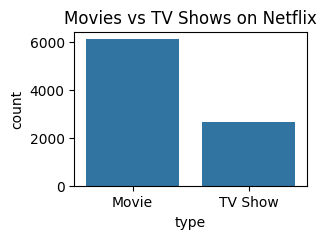

In [ ]:
plt.figure(figsize=(3,2))
sns.countplot(x='type',data=data)
plt.title("Movies vs TV Shows on Netflix")
plt.show()


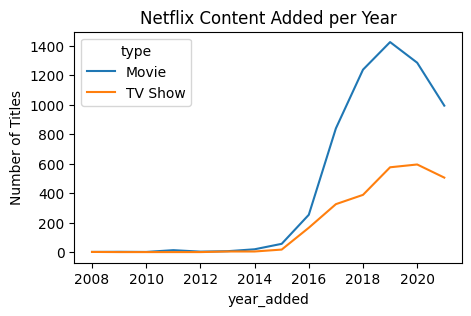

In [ ]:
year_type = data.groupby(['year_added','type']).size().unstack().fillna(0)
year_type.plot(figsize=(5,3))
plt.title("Netflix Content Added per Year")
plt.ylabel("Number of Titles")
plt.show()

**Observation:**
Movies dominate the platform overall


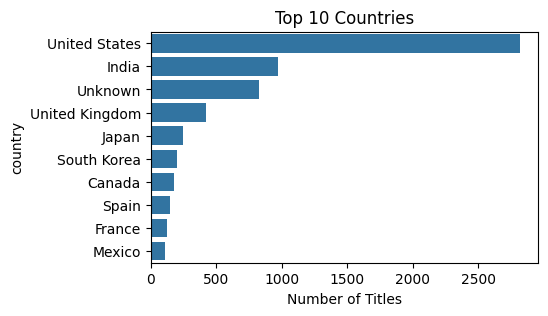

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(x=country_count.values, y=country_count.index)
plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")
plt.show()


**Observation**:
U.S tops the list while India and U.K growing rapidly

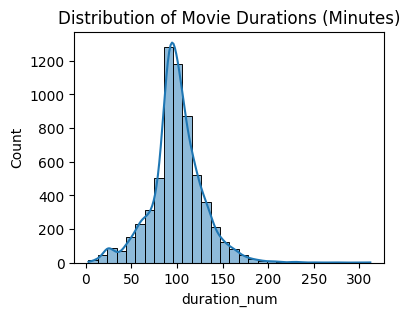

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(data[data['type']=='Movie']['duration_num'].dropna(), bins=30, kde=True)
plt.title("Distribution of Movie Durations (Minutes)")
plt.show()


Observation: Most movies range between 80–120 minutes — typical feature film lengths.

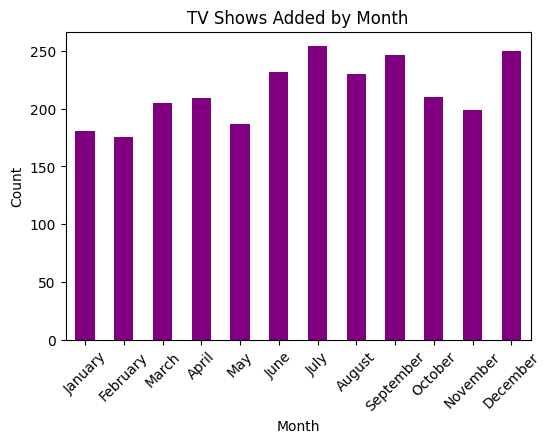

In [ ]:
data['month_added'] = data['date_added'].dt.month_name()
#plotting graph
tv_month.plot(kind='bar', figsize=(6,4), color='Purple')
plt.title("TV Shows Added by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


**Observation**:
The number of shows added peaks in June–September and December

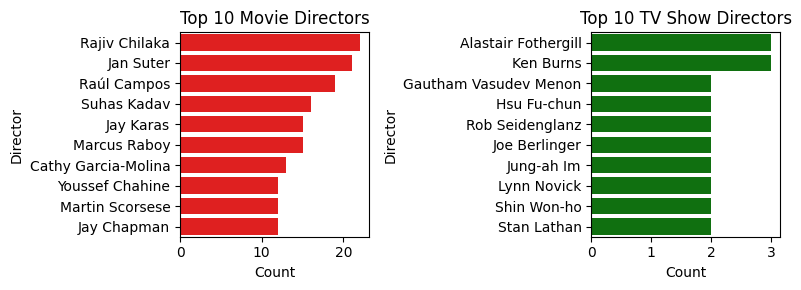

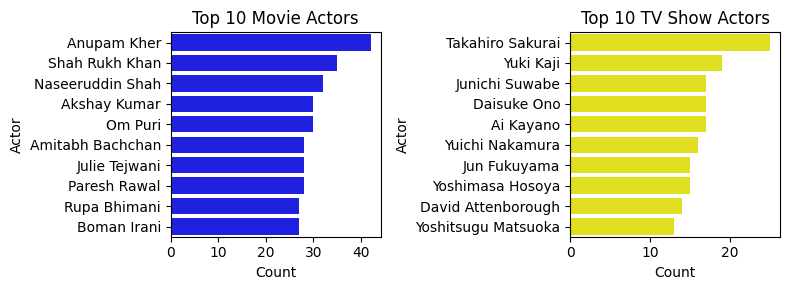

In [ ]:
# Handle missing values
data['director'] = data['director'].fillna('Unknown')
data['cast'] = data['cast'].fillna('Unknown')

# Split director and cast into lists
data['director_list'] = data['director'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])
data['cast_list'] = data['cast'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])
from collections import Counter

# Separate Movies and TV Shows
movies = data[data['type'] == 'Movie']
tv_shows = data[data['type'] == 'TV Show']

# Count directors
movie_directors = Counter([d for sublist in movies['director_list'] for d in sublist])
tv_directors = Counter([d for sublist in tv_shows['director_list'] for d in sublist])

# Convert to DataFrame for plotting
top_movie_dir = pd.DataFrame(movie_directors.most_common(10), columns=['Director', 'Count'])
top_tv_dir = pd.DataFrame(tv_directors.most_common(10), columns=['Director', 'Count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.barplot(x='Count', y='Director', data=top_movie_dir, ax=axes[0], color='red')
axes[0].set_title('Top 10 Movie Directors')
sns.barplot(x='Count', y='Director', data=top_tv_dir, ax=axes[1], color='green')
axes[1].set_title('Top 10 TV Show Directors')
plt.tight_layout()
plt.show()
movie_actors = Counter([a for sublist in movies['cast_list'] for a in sublist])
tv_actors = Counter([a for sublist in tv_shows['cast_list'] for a in sublist])

top_movie_act = pd.DataFrame(movie_actors.most_common(10), columns=['Actor', 'Count'])
top_tv_act = pd.DataFrame(tv_actors.most_common(10), columns=['Actor', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.barplot(x='Count', y='Actor', data=top_movie_act, ax=axes[0], color='blue')
axes[0].set_title('Top 10 Movie Actors')
sns.barplot(x='Count', y='Actor', data=top_tv_act, ax=axes[1], color='yellow')
axes[1].set_title('Top 10 TV Show Actors')
plt.tight_layout()
plt.show()


**Insights**:

Anupam Kher and Rajiv Chilaka frequently appear in movies.

Alastair Fothergill and Takahiro Sakurai often appears in TV Shows

International Movies,Dramas and Comedies are well performing genres



### Key Insights
1. Netflix’s content library has **grown exponentially after 2015**.  
2. Movies dominate the platform overall
3. **Drama, International, and Comedy** genres dominate — they attract broad global audiences.  
4. The **U.S., India, and the U.K.** are leading in content production.  
5. **Most shows are added during June-september**, december indicating strategic release planning.  
6. **Average movie duration** lies between 80–120 minutes, preferred by most viewers.  
7. A few **actors and directors** appear frequently, showing Netflix’s reliance on popular creators.


### Actionable Recommendations
1. **Expand localized content** in emerging markets (e.g., Japan, South Korea, Brazil) with fewer native titles.  
2. **Launch family-friendly and educational content** to attract multi-age audiences.  
4. **Plan major releases in Q3-Q4 (June–Dec)** to align with holiday viewership spikes.  
5. **Collaborate with top regional directors and actors** to strengthen brand visibility.  
6. **Diversify runtime and formats** — short documentaries, mini-series, and reality formats for variety.  
7. **Use data-driven recommendations** to curate localized homepages by region.  
8. **Pilot local remakes** of successful global formats to reduce creative risk.  
